In [1]:
!pip install -q torch torchvision
!pip install -q open_clip_torch
!pip install -q scikit-learn tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [2]:
import time
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor()
])

dataset = datasets.FashionMNIST(

    root="./data",
    train=False,
    download=True,
    transform=transform
)

loader = DataLoader(

    dataset,
    batch_size=32,
    shuffle=False
)

print("Total Images:", len(dataset))

print("Classes:", dataset.classes)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 224kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.6MB/s]

Total Images: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
clip_model, _, preprocess = open_clip.create_model_and_transforms(

    'ViT-B-32',
    pretrained='openai'
)

clip_model = clip_model.to(device)

clip_model.eval()

print("CLIP MODEL LOADED")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP MODEL LOADED


In [6]:
def benchmark_clip_model(model, loader):

    embeddings = []
    all_labels = []

    total_time = 0
    total_images = 0

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            start = time.time()

            features = model.encode_image(images)

            end = time.time()

            total_time += (end - start)

            total_images += images.size(0)

            features = features.cpu().numpy()

            embeddings.append(features)

            all_labels.append(labels.numpy())

    embeddings = np.concatenate(embeddings, axis=0)

    all_labels = np.concatenate(all_labels, axis=0)

    fps = total_images / total_time

    latency = total_time / total_images

    if torch.cuda.is_available():

        gpu_memory = (
            torch.cuda.max_memory_allocated() / 1024**3
        )

    else:
        gpu_memory = 0

    return {

        "embeddings": embeddings,
        "labels": all_labels,
        "fps": fps,
        "latency": latency,
        "gpu_memory": gpu_memory
    }

In [7]:
clip_results = benchmark_clip_model(

    clip_model,
    loader
)

100%|██████████| 313/313 [00:35<00:00,  8.75it/s]


In [8]:
X = clip_results["embeddings"]

y = clip_results["labels"]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

predictions = knn.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

In [9]:
print("\n========== CLIP FINAL RESULTS ==========")

print("Accuracy      :", round(accuracy * 100, 2), "%")

print("FPS           :", round(clip_results["fps"], 2))

print("Latency       :", round(clip_results["latency"], 5))

print("GPU Memory GB :", round(clip_results["gpu_memory"], 2))


========== CLIP FINAL RESULTS ==========
Accuracy      : 81.9 %
FPS           : 3519.72
Latency       : 0.00028
GPU Memory GB : 0.65


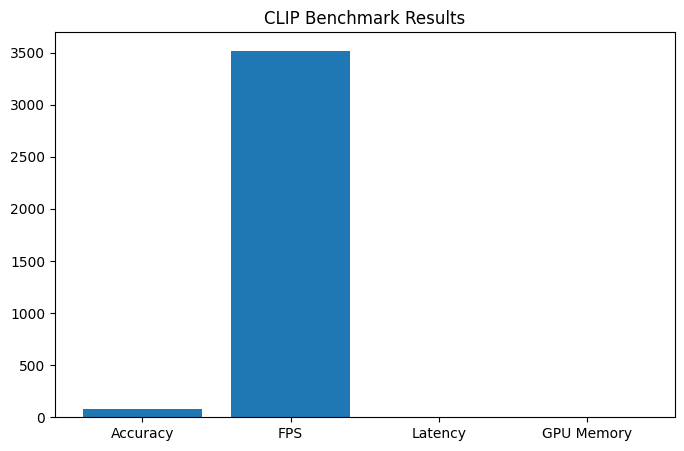

In [10]:
metrics = [

    round(accuracy * 100, 2),

    round(clip_results["fps"], 2),

    round(clip_results["latency"], 5),

    round(clip_results["gpu_memory"], 2)
]

metric_names = [

    "Accuracy",
    "FPS",
    "Latency",
    "GPU Memory"
]

plt.figure(figsize=(8,5))

plt.bar(metric_names, metrics)

plt.title("CLIP Benchmark Results")

plt.show()